# 03 · Modeling & Evaluation
**Project**: Retail Revenue Forecasting — Olist Brazil E-commerce

**Mục tiêu :**
- So sánh các model: Baseline → Linear Regression → Random Forest → XGBoost
- Cross-validate với TimeSeriesSplit
- Visualize actual vs predicted
- Feature importance & business interpretation

## 0. Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.data_loader import load_raw_tables, build_master_df, build_daily_series
from src.features import build_feature_matrix, FEATURE_COLS, TARGET_COL
from src.evaluate import (
    time_series_cv, baseline_last_week,
    plot_model_comparison, plot_predictions, plot_feature_importance,
)
IMAGES_DIR = Path("../images")
DATA_DIR   = "../data/"

In [2]:
tables     = load_raw_tables(DATA_DIR)
df         = build_master_df(tables)
daily      = build_daily_series(df)
feature_df = build_feature_matrix(daily)

X = feature_df[FEATURE_COLS]
y = feature_df[TARGET_COL]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Date range: {feature_df['date'].min().date()} → {feature_df['date'].max().date()}")

Feature matrix: 666 rows × 25 cols
Features: ['lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'month', 'quarter', 'dayofweek', 'day', 'is_weekend', 'days_to_month_end', 'week_of_year', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_holiday', 'is_pre_holiday', 'is_post_holiday']
X shape: (666, 19)
y shape: (666,)
Date range: 2016-11-02 → 2018-08-29


## 1. Baseline — Moving Average (lag_7)


In [3]:
print("=== Baseline: Predict = Revenue 7 days ago ===")
baseline_metrics = baseline_last_week(feature_df)

=== Baseline: Predict = Revenue 7 days ago ===
  Baseline (lag_7) — MAE: 9,400 | MAPE: 294594628.9%


## 2. Linear Regression


In [4]:
print("\n=== Linear Regression (L2) ===")
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),   # LR cần scale features
    ("model",  Ridge(alpha=1.0)),
])

lr_results = time_series_cv(lr_pipe, X, y, n_splits=5)
print(f"\n  CV Mean MAE  : {lr_results['mean_MAE']:,.0f} BRL")
print(f"  CV Mean RMSE : {lr_results['mean_RMSE']:,.0f} BRL")
print(f"  CV Mean MAPE : {lr_results['mean_MAPE']:.1f}%")


=== Linear Regression (L2) ===
  Fold 1/5 — MAE:   18,170 | RMSE:   19,838 | MAPE: 102.4%
  Fold 2/5 — MAE:    8,493 | RMSE:   15,694 | MAPE:  28.4%
  Fold 3/5 — MAE:   12,378 | RMSE:   24,948 | MAPE:  34.3%
  Fold 4/5 — MAE:   12,778 | RMSE:   15,065 | MAPE:  31.8%
  Fold 5/5 — MAE:   10,568 | RMSE:   13,282 | MAPE:  40.3%

  CV Mean MAE  : 12,477 BRL
  CV Mean RMSE : 17,765 BRL
  CV Mean MAPE : 47.4%


## 3. Random Forest


In [5]:
print("\n=== Random Forest Regressor ===")
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

rf_results = time_series_cv(rf, X, y, n_splits=5)
print(f"\n  CV Mean MAE  : {rf_results['mean_MAE']:,.0f} BRL")
print(f"  CV Mean RMSE : {rf_results['mean_RMSE']:,.0f} BRL")
print(f"  CV Mean MAPE : {rf_results['mean_MAPE']:.1f}%")


=== Random Forest Regressor ===
  Fold 1/5 — MAE:    6,899 | RMSE:    8,700 | MAPE:  34.6%
  Fold 2/5 — MAE:    6,903 | RMSE:   14,323 | MAPE:  23.0%
  Fold 3/5 — MAE:   13,906 | RMSE:   26,694 | MAPE:  37.5%
  Fold 4/5 — MAE:   11,377 | RMSE:   15,217 | MAPE:  26.3%
  Fold 5/5 — MAE:   10,692 | RMSE:   13,263 | MAPE:  44.7%

  CV Mean MAE  : 9,956 BRL
  CV Mean RMSE : 15,639 BRL
  CV Mean MAPE : 33.2%


## 4. Gradient Boosting


In [6]:
print("\n=== Gradient Boosting Regressor ===")
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42,
)

gb_results = time_series_cv(gb, X, y, n_splits=5)
print(f"\n  CV Mean MAE  : {gb_results['mean_MAE']:,.0f} BRL")
print(f"  CV Mean RMSE : {gb_results['mean_RMSE']:,.0f} BRL")
print(f"  CV Mean MAPE : {gb_results['mean_MAPE']:.1f}%")


=== Gradient Boosting Regressor ===
  Fold 1/5 — MAE:    8,255 | RMSE:   10,106 | MAPE:  42.6%
  Fold 2/5 — MAE:    8,603 | RMSE:   15,757 | MAPE:  29.3%
  Fold 3/5 — MAE:   16,399 | RMSE:   29,576 | MAPE:  47.3%
  Fold 4/5 — MAE:   18,892 | RMSE:   29,789 | MAPE:  46.6%
  Fold 5/5 — MAE:   10,076 | RMSE:   12,626 | MAPE:  41.1%

  CV Mean MAE  : 12,445 BRL
  CV Mean RMSE : 19,571 BRL
  CV Mean MAPE : 41.4%


## 5. Model Comparison

Saved: ..\images\model_comparison.png


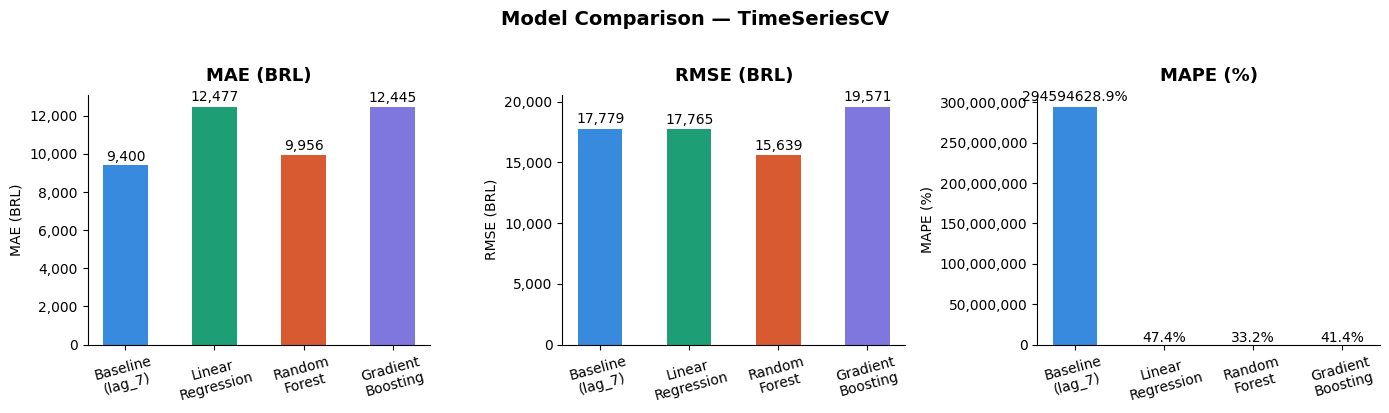

In [7]:
all_results = {
    "Baseline\n(lag_7)":    {"mean_MAE": baseline_metrics["MAE"],
                             "mean_RMSE": baseline_metrics["RMSE"],
                             "mean_MAPE": baseline_metrics["MAPE"]},
    "Linear\nRegression":   lr_results,
    "Random\nForest":       rf_results,
    "Gradient\nBoosting":   gb_results,
}

plot_model_comparison(
    all_results,
    save_path=str(IMAGES_DIR / "model_comparison.png")
)

In [ ]:
print("\n=== Model Comparison Table (copy vào README) ===")
print("| Model | MAE (BRL) | RMSE (BRL) | MAPE (%) |")
print("|-------|----------|-----------|---------|")
model_names_clean = ["Baseline (lag_7)", "Linear Regression (Ridge)", "Random Forest", "Gradient Boosting"]
for name, r in zip(model_names_clean, all_results.values()):
    print(f"| {name} | {r['mean_MAE']:,.0f} | {r['mean_RMSE']:,.0f} | {r['mean_MAPE']:.1f} |")


=== Model Comparison Table (copy vào README) ===
| Model          | MAE (BRL)  | RMSE (BRL)  | MAPE (%)  |
|-------         | ---------- | ----------- | --------- |
| Baseline (lag_7) | 9,400 | 17,779 | 294594628.9 |
| Linear Regression (Ridge) | 12,477 | 17,765 | 47.4 |
| Random Forest | 9,956 | 15,639 | 33.2 |
| Gradient Boosting | 12,445 | 19,571 | 41.4 |


## 6. Best Model — Actual vs Predicted Plot

Saved: ..\images\actual_vs_predicted.png


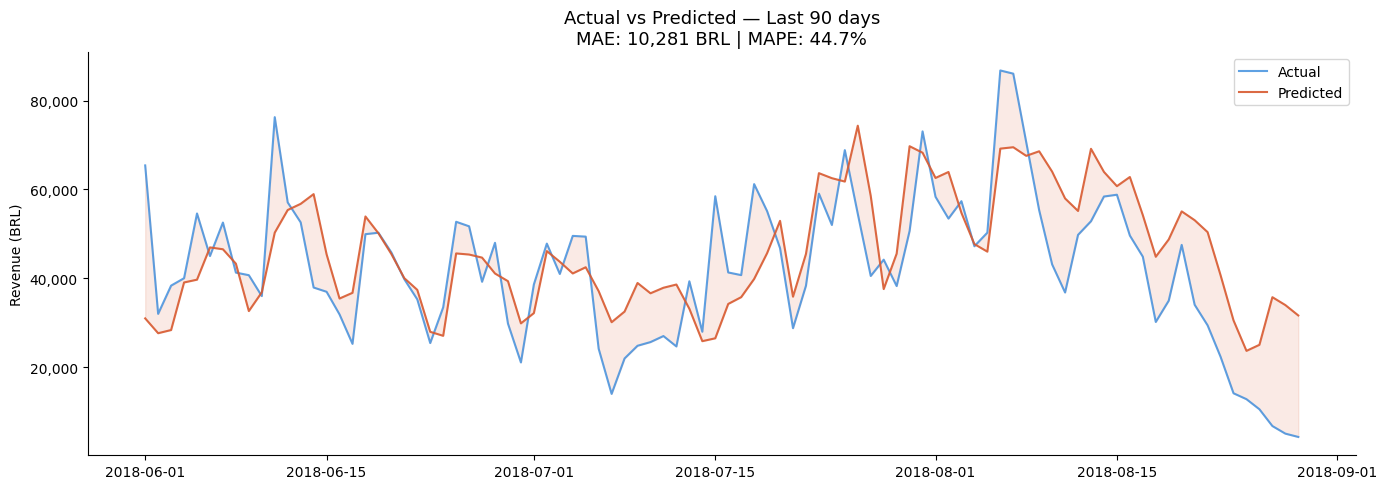


Hold-out set (last 90 days):
  MAE : 10,281 BRL
  RMSE: 12,903 BRL
  MAPE: 44.7%


In [9]:
best_model = rf

best_metrics = plot_predictions(
    feature_df, best_model, FEATURE_COLS,
    last_n_days=90,
    save_path=str(IMAGES_DIR / "actual_vs_predicted.png"),
)
print(f"\nHold-out set (last 90 days):")
print(f"  MAE : {best_metrics['MAE']:,.0f} BRL")
print(f"  RMSE: {best_metrics['RMSE']:,.0f} BRL")
print(f"  MAPE: {best_metrics['MAPE']:.1f}%")

## 7. Feature Importance

Saved: ..\images\feature_importance.png


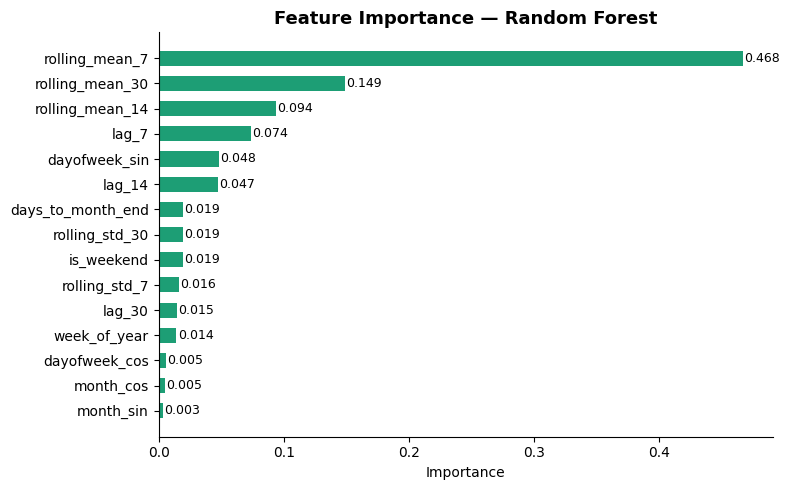

In [10]:
best_model.fit(X, y)

plot_feature_importance(
    best_model, FEATURE_COLS, top_n=15,
    save_path=str(IMAGES_DIR / "feature_importance.png"),
)

In [11]:
importance_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))


Top 10 most important features:
          feature  importance
   rolling_mean_7    0.467541
  rolling_mean_30    0.149094
  rolling_mean_14    0.093579
            lag_7    0.073984
    dayofweek_sin    0.048284
           lag_14    0.047283
days_to_month_end    0.019409
   rolling_std_30    0.019378
       is_weekend    0.019372
    rolling_std_7    0.016109


## 8. Residual Analysis

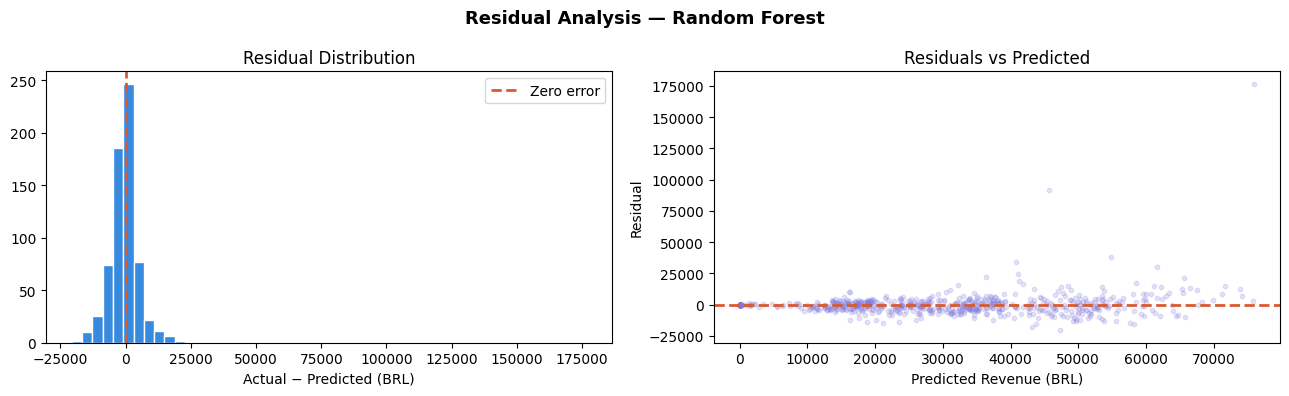

In [12]:
preds_all = best_model.predict(X)
residuals = y.values - preds_all

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals, bins=50, color="#378ADD", edgecolor="white")
axes[0].axvline(0, color="#D85A30", linewidth=2, linestyle="--", label="Zero error")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Actual − Predicted (BRL)")
axes[0].legend()

axes[1].scatter(preds_all, residuals, alpha=0.2, s=10, color="#7F77DD")
axes[1].axhline(0, color="#D85A30", linewidth=2, linestyle="--")
axes[1].set_xlabel("Predicted Revenue (BRL)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

plt.suptitle("Residual Analysis — Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "residuals.png", dpi=150, bbox_inches="tight")
plt.show()